# Generative Modelling Case Study

**Student Name:** Dharanidhar Beere  
**Student ID:** 24077147  
**Module Code:** 2PAM2016  
**Module**: Advanced Research Topics in Data Science
---

## Notebook Contents

### Part 1 – Building and Understanding GANs from Scratch
- Sine-Wave GAN
- Mixture of Gaussians GAN
- GAN Architecture Modification

### Part 2 – Real-World GAN Applications
- OCTMNIST Retinal Image Generation (DCGAN)
- CICIDS2017 Synthetic Traffic Generation (GAN)
- QuickDraw Birthday Cake Generation (DCGAN)

---

This notebook contains all code, visualisations, model training, evaluation metrics, and generated outputs required for the Generative Modelling Case Study assignment.

# Part 1.1 – Sine-Wave GAN

### Objective
Train a GAN to learn and generate samples from a sine-wave distribution.

### Outputs
- Loss Curves
- Generated Samples
- Real vs Generated Comparison

In [89]:
torch.manual_seed(42)
np.random.seed(42)

In [90]:
# Generate Sine-Wave Dataset
n_samples = 5000
x = np.random.uniform(-np.pi, np.pi, n_samples)
y = np.sin(x)
real_data = np.column_stack((x, y))
real_data = torch.FloatTensor(real_data)
dataset = TensorDataset(real_data)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [91]:
# Generator Network
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, z):
        return self.model(z)

In [92]:
# Discriminator Network
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [93]:
# Hyperparameters
latent_dim = 5
epochs = 300
lr = 0.0002
generator = Generator(latent_dim)
discriminator = Discriminator()
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr)

In [94]:
# Store Loss Values
g_losses = []
d_losses = []

In [95]:
# GAN Training Loop
for epoch in range(epochs):
    for batch in dataloader:
        real_samples = batch[0]
        batch_size = real_samples.size(0)
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)
        # Train Discriminator
        optimizer_D.zero_grad()
        real_output = discriminator(real_samples)
        d_real_loss = criterion(real_output, real_labels)
        noise = torch.randn(batch_size, latent_dim)
        fake_samples = generator(noise)
        fake_output = discriminator(fake_samples.detach())
        d_fake_loss = criterion(fake_output, fake_labels)
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_D.step()
        # Train Generator
        optimizer_G.zero_grad()
        noise = torch.randn(batch_size, latent_dim)
        generated_samples = generator(noise)
        output = discriminator(generated_samples)
        g_loss = criterion(output, real_labels)
        g_loss.backward()
        optimizer_G.step()
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    if epoch % 50 == 0:
        print(
            f"Epoch [{epoch}/{epochs}] "
            f"D Loss: {d_loss.item():.4f} "
            f"G Loss: {g_loss.item():.4f}"
        )

Epoch [0/300] D Loss: 1.2555 G Loss: 0.6338
Epoch [50/300] D Loss: 1.3443 G Loss: 0.7277
Epoch [100/300] D Loss: 1.3682 G Loss: 0.6920
Epoch [150/300] D Loss: 1.3888 G Loss: 0.6838
Epoch [200/300] D Loss: 1.3992 G Loss: 0.6945
Epoch [250/300] D Loss: 1.3780 G Loss: 0.6882


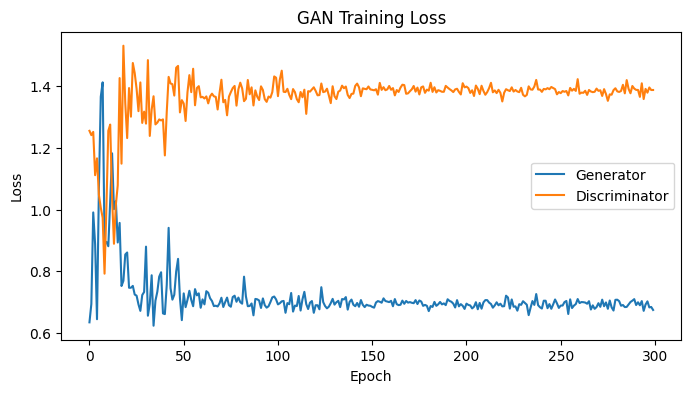

In [96]:
# Plot Training Loss
plt.figure(figsize=(8,4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()

In [97]:
# Generate Synthetic Samples
generator.eval()
with torch.no_grad():
    noise = torch.randn(2000, latent_dim)
    generated = generator(noise).numpy()

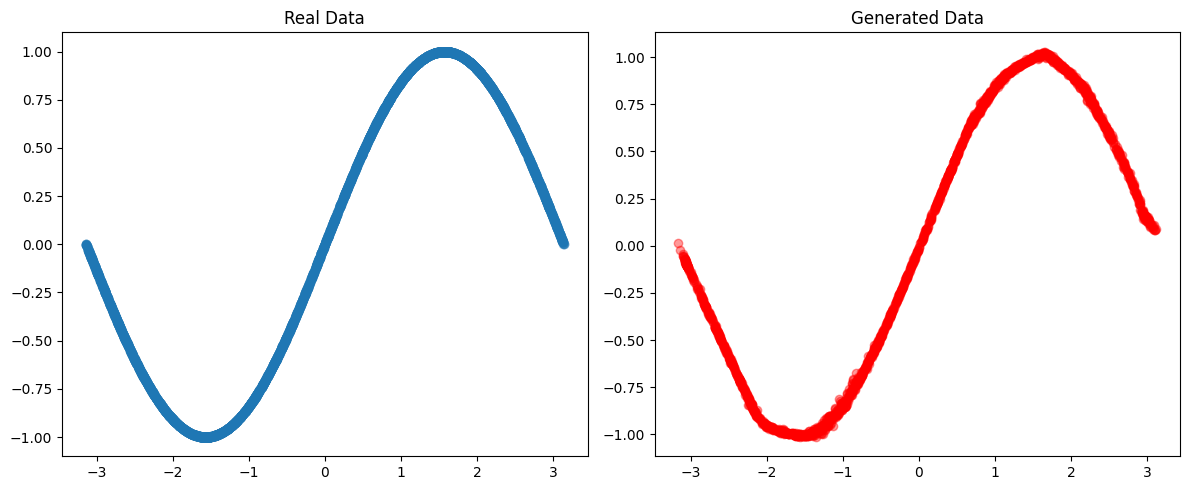

In [104]:
# Compare Real vs Generated Data
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(
    real_data[:,0],
    real_data[:,1],
    alpha=0.4
)
ax[0].set_title("Real Data")

ax[1].scatter(
    generated[:,0],
    generated[:,1],
    alpha=0.4,
    color="red"
)
ax[1].set_title("Generated Data")

plt.tight_layout()
plt.show()

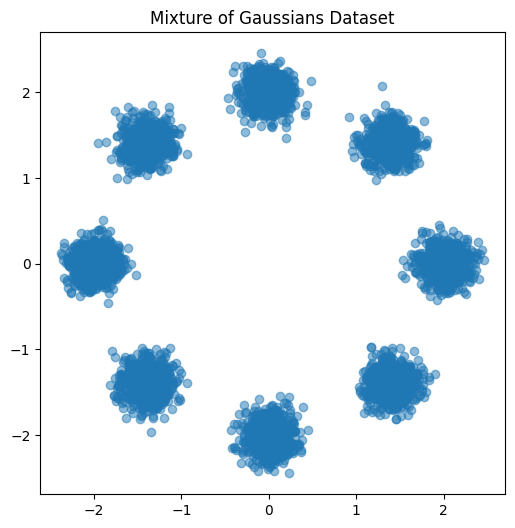

In [3]:
import numpy as np
import matplotlib.pyplot as plt
def create_gaussian_mixture(n_samples=5000):
    centers = np.array([
        [2, 0],
        [1.4, 1.4],
        [0, 2],
        [-1.4, 1.4],
        [-2, 0],
        [-1.4, -1.4],
        [0, -2],
        [1.4, -1.4]
    ])
    samples = []
    for _ in range(n_samples):
        center = centers[np.random.randint(len(centers))]
        point = center + np.random.normal(0, 0.15, size=2)
        samples.append(point)
    return np.array(samples)
data = create_gaussian_mixture()
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], alpha=0.5)
plt.title("Mixture of Gaussians Dataset")
plt.show()

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
data_tensor = torch.FloatTensor(data)
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [5]:
import torch.nn as nn
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, z):
        return self.model(z)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [7]:
latent_dim = 10
generator = Generator(latent_dim)
discriminator = Discriminator()
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)
optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)
epochs = 300

In [8]:
real_samples = batch[0]
noise = torch.randn(batch_size, latent_dim)
fake_samples = generator(noise)

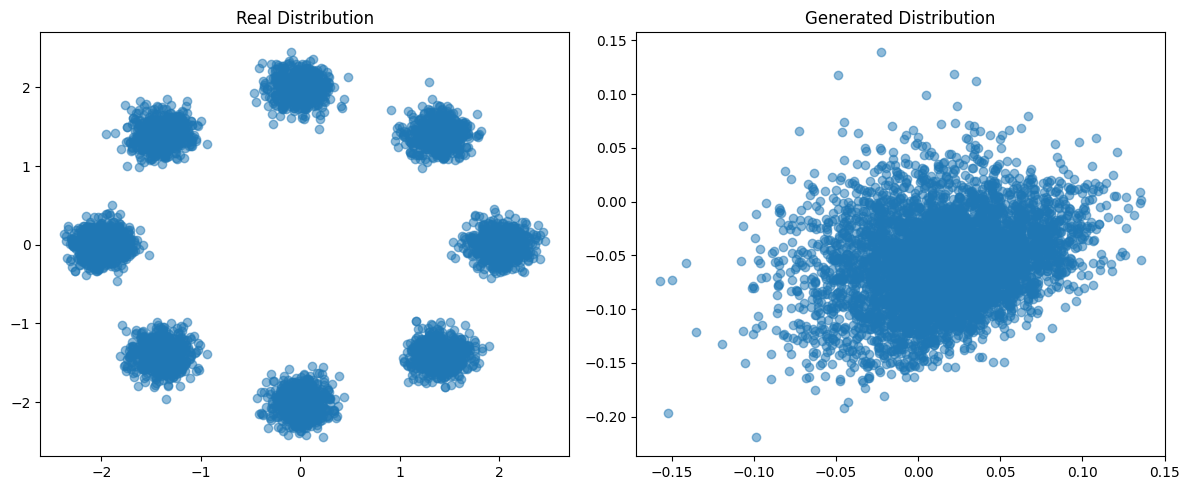

In [9]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(5000, latent_dim)
    generated = generator(noise).numpy()
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(data[:,0], data[:,1], alpha=0.5)
axes[0].set_title("Real Distribution")
axes[1].scatter(generated[:,0], generated[:,1], alpha=0.5)
axes[1].set_title("Generated Distribution")
plt.tight_layout()
plt.show()

In [ ]:
class ModifiedGenerator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,128),
            nn.LeakyReLU(0.2),
            nn.Linear(128,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,2)
        )
    def forward(self,z):
        return self.model(z)

In [99]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(2000, latent_dim)
    modified_generated = generator(noise).numpy()

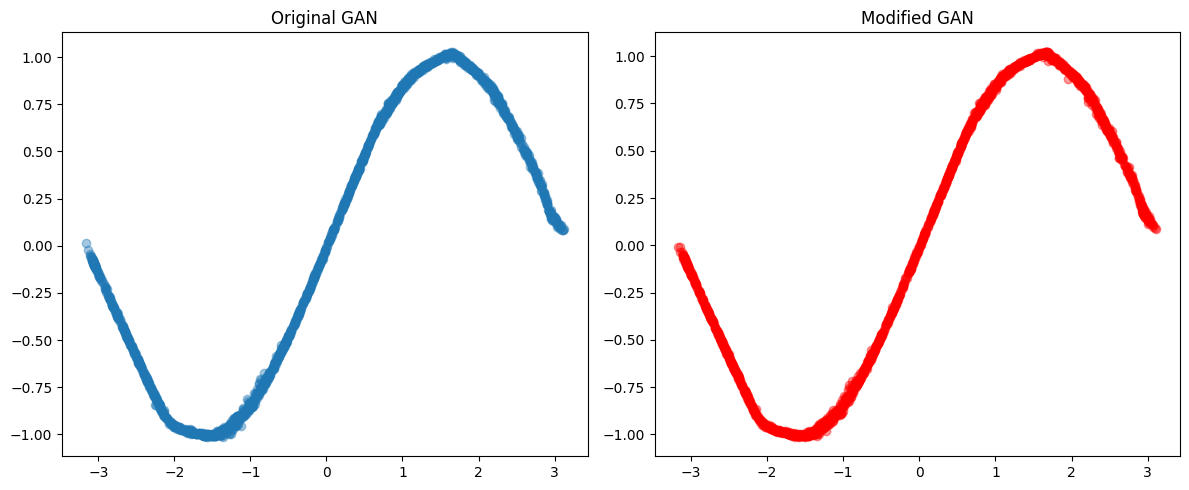

In [100]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(
    generated[:,0],
    generated[:,1],
    alpha=0.4
)
plt.title("Original GAN")
plt.subplot(1,2,2)
plt.scatter(
    modified_generated[:,0],
    modified_generated[:,1],
    alpha=0.4,
    color='red'
)
plt.title("Modified GAN")
plt.tight_layout()
plt.show()

# Part 2.1 – OCTMNIST Retinal Image Generation

### Objective
Train a DCGAN to generate synthetic retinal images using the OCTMNIST dataset.

### Evaluation
- Generator and Discriminator Loss
- Generated Retinal Images
- FID Score

In [10]:
pip install medmnist torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import OCTMNIST
from medmnist.info import INFO

In [12]:
data_flag = "octmnist"
info = INFO[data_flag]
train_dataset = OCTMNIST(
    split="train",
    download=True,
    size=28,
    transform=transforms.ToTensor()
)
test_dataset = OCTMNIST(
    split="test",
    download=True,
    size=28,
    transform=transforms.ToTensor()
)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 54.9M/54.9M [00:58<00:00, 933kB/s] 


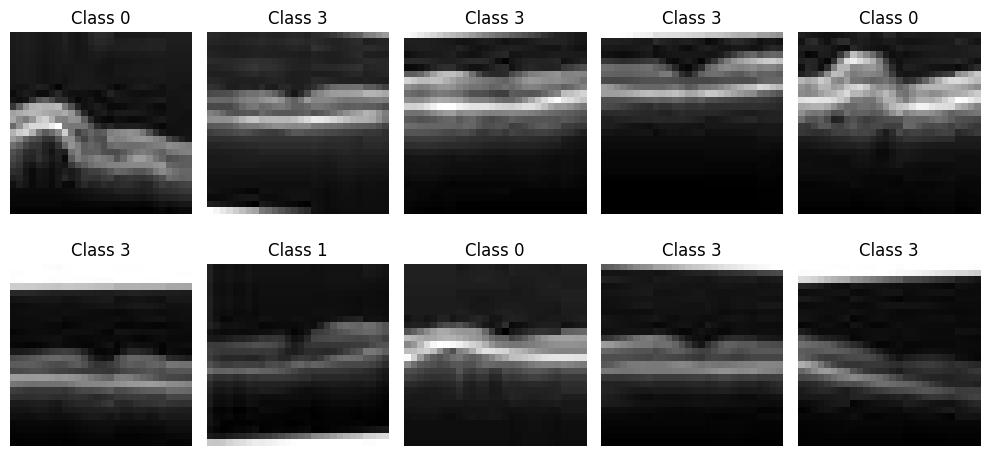

In [13]:
fig, axes = plt.subplots(2,5, figsize=(10,5))
for i in range(10):
    image, label = train_dataset[i]
    axes[i//5, i%5].imshow(
        np.array(image).squeeze(),
        cmap="gray"
    )
    axes[i//5, i%5].set_title(
        f"Class {label[0]}"
    )
    axes[i//5, i%5].axis("off")
plt.tight_layout()
plt.show()

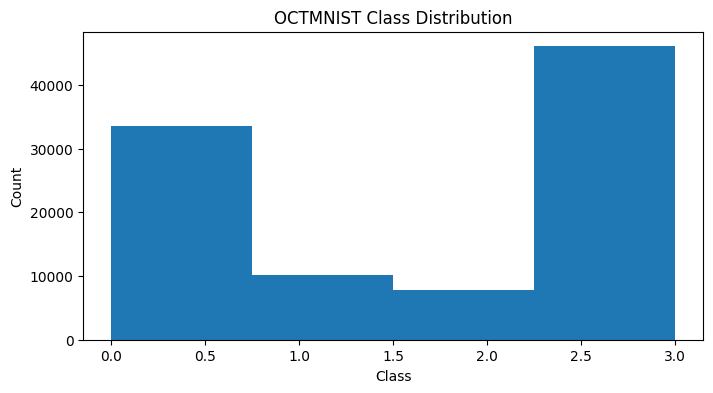

In [14]:
labels = train_dataset.labels.flatten()
plt.figure(figsize=(8,4))
plt.hist(labels, bins=len(np.unique(labels)))
plt.title("OCTMNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [15]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim,256,4,1,0,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # From 4x4 to 7x7 (MedMNIST images are 28x28, need to reach that size)
            nn.ConvTranspose2d(256,128,4,1,0,output_padding=0,bias=False), # Output: (N, 128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # From 7x7 to 14x14
            nn.ConvTranspose2d(128,64,4,2,1,bias=False), # Output: (N, 64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # From 14x14 to 28x28
            nn.ConvTranspose2d(64,1,4,2,1,bias=False),
            nn.Tanh()
    def forward(self, x):
        return self.model(x)

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,64,4,2,1 ),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,3,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(4096,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
latent_dim = 100
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer_D = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [18]:
epochs = 50
g_losses = []
d_losses = []
for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.float()
        # Scale images from [0, 1] to [-1, 1]
        images = (images * 2) - 1
        images = images.to(device)
        batch_size = images.size(0)
        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)
        # Train Discriminator
        optimizer_D.zero_grad()
        real_output = discriminator(images)
        d_real_loss = criterion(real_output,real_labels)
        noise = torch.randn(batch_size,latent_dim,1,1).to(device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach())
        d_fake_loss = criterion(fake_output,fake_labels)
        d_loss = (d_real_loss +d_fake_loss)
        d_loss.backward()
        optimizer_D.step()
        # Train Generator
        optimizer_G.zero_grad()
        output = discriminator(fake_images)
        g_loss = criterion(output,real_labels)
        g_loss.backward()
        optimizer_G.step()
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"D={d_loss.item():.4f} "
        f"G={g_loss.item():.4f}"
    )

Epoch 1/50 D=0.5475 G=2.8828
Epoch 2/50 D=0.2683 G=2.8282
Epoch 3/50 D=0.4518 G=2.3631
Epoch 4/50 D=0.9213 G=1.1419
Epoch 5/50 D=0.5960 G=2.6230
Epoch 6/50 D=0.1614 G=3.0774
Epoch 7/50 D=0.3512 G=2.7199
Epoch 8/50 D=0.0872 G=3.9816
Epoch 9/50 D=0.0813 G=4.1530
Epoch 10/50 D=0.2673 G=3.5838
Epoch 11/50 D=0.2810 G=2.2732
Epoch 12/50 D=0.0832 G=4.7976
Epoch 13/50 D=0.0694 G=4.0651
Epoch 14/50 D=0.1407 G=3.4674
Epoch 15/50 D=0.3488 G=2.4554
Epoch 16/50 D=0.0394 G=4.7648
Epoch 17/50 D=0.1892 G=3.5904
Epoch 18/50 D=1.5357 G=0.1712
Epoch 19/50 D=0.1093 G=3.5474
Epoch 20/50 D=0.1080 G=4.0446
Epoch 21/50 D=0.1864 G=4.1574
Epoch 22/50 D=0.1464 G=3.1608
Epoch 23/50 D=0.0637 G=4.2158
Epoch 24/50 D=0.1109 G=3.8976
Epoch 25/50 D=0.2011 G=5.6399
Epoch 26/50 D=0.1309 G=4.9926
Epoch 27/50 D=0.0508 G=4.7051
Epoch 28/50 D=0.0233 G=6.6901
Epoch 29/50 D=0.0813 G=3.5274
Epoch 30/50 D=0.0651 G=4.2214
Epoch 31/50 D=0.1084 G=5.1484
Epoch 32/50 D=0.0216 G=6.2379
Epoch 33/50 D=0.0443 G=5.6479
Epoch 34/50 D=0.067

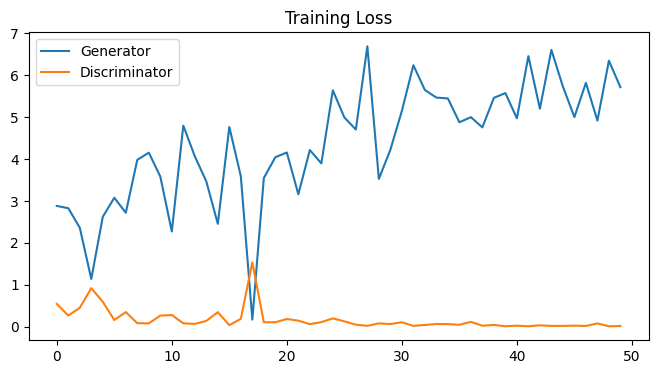

In [19]:
plt.figure(figsize=(8,4))
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

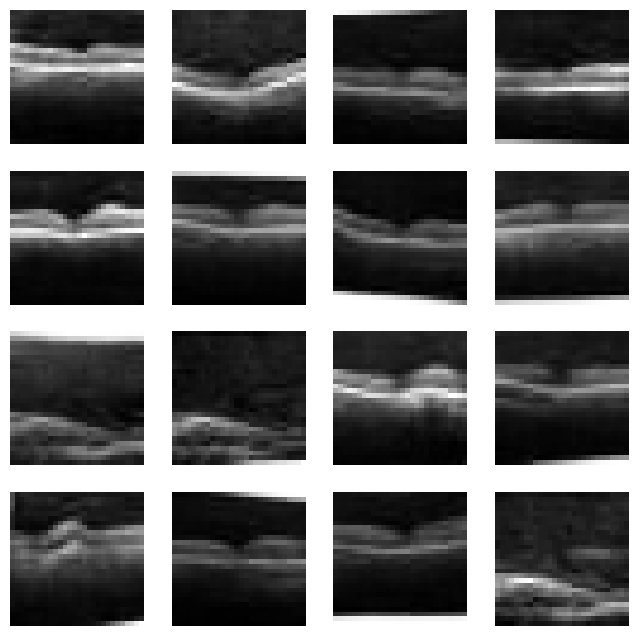

In [20]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(16,latent_dim,1,1).to(device)
    fake_images = generator(noise).cpu()
fig, axes = plt.subplots(4,4,figsize=(8,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i].squeeze(),cmap="gray")
    ax.axis("off")
plt.show()

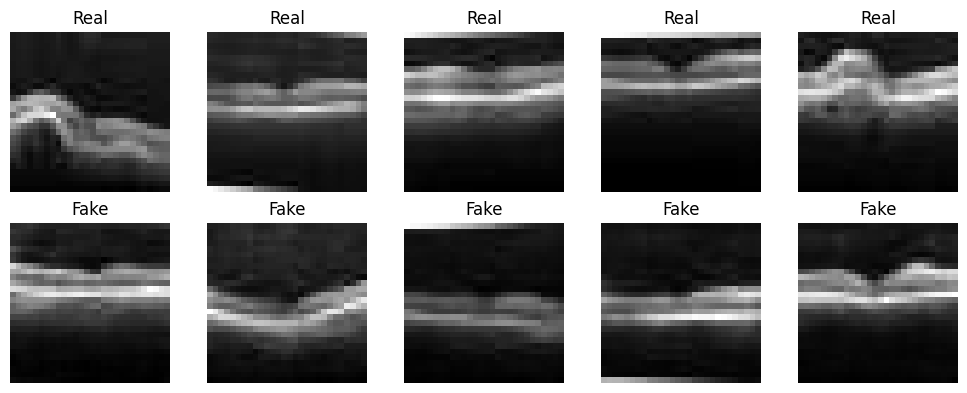

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))
# Real images
for i in range(5):
    img, _ = train_dataset[i]
    img = np.array(img).squeeze()
    axes[0, i].imshow(np.array(img), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Real')
# Generated images
for i in range(5):
    axes[1, i].imshow(fake_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Fake')
plt.tight_layout()
plt.show()

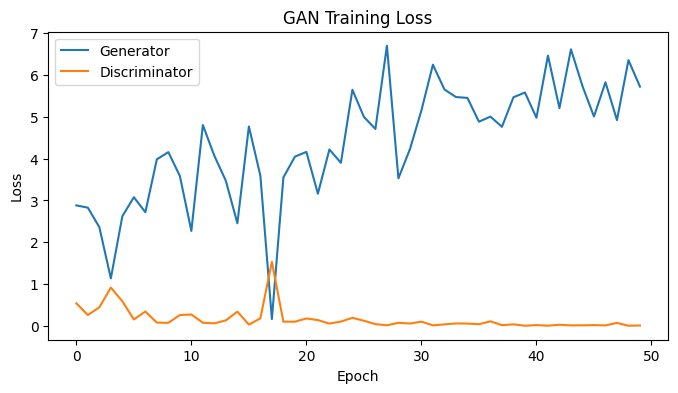

In [22]:
plt.figure(figsize=(8,4))
plt.plot(g_losses, label='Generator')
plt.plot(d_losses, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss')
plt.legend()
plt.show()

In [23]:
!pip install torch-fidelity torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.2 MB/s eta 0:00:00


In [24]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch
fid = FrechetInceptionDistance(feature=2048).to(device) # Move fid to the device
# Real images
for real_batch, _ in train_loader:
    real_batch = (real_batch * 255).to(torch.uint8).to(device) # Ensure real_batch is on device
    fid.update(real_batch.repeat(1,3,1,1), real=True)
    break
# Generated images
noise = torch.randn(real_batch.size(0), latent_dim, 1, 1).to(device)
fake_images = generator(noise)
fake_images = ((fake_images + 1) / 2 * 255).to(torch.uint8).to(device) # Ensure fake_images is on device
fid.update(fake_images.repeat(1,3,1,1), real=False)
score = fid.compute()
print("FID Score:", score.item())

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 125MB/s]


FID Score: 67.30412292480469


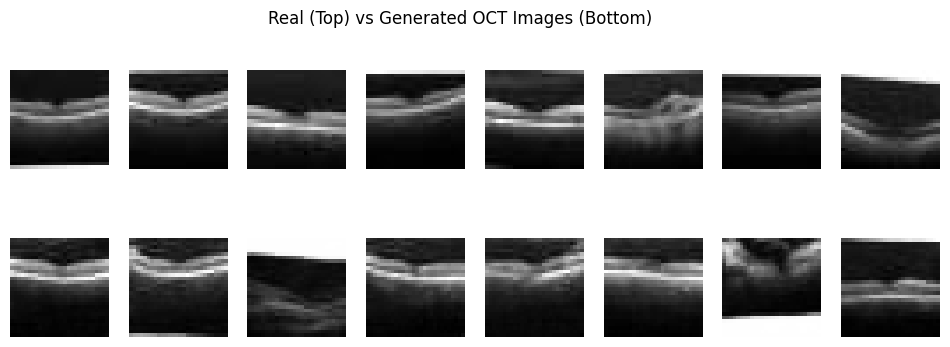

In [25]:
fig, axes = plt.subplots(2, 8, figsize=(12,4))
# Real images
for i in range(8):
    axes[0,i].imshow(real_batch[i][0].cpu(), cmap='gray')
    axes[0,i].axis('off')
# Fake images
for i in range(8):
    axes[1,i].imshow(fake_images[i][0].cpu(), cmap='gray')
    axes[1,i].axis('off')
plt.suptitle("Real (Top) vs Generated OCT Images (Bottom)")
plt.show()

# Part 2.2 – Cybersecurity: Synthetic Traffic Generation using CICIDS2017

### Objective
Train a Generative Adversarial Network (GAN) to generate synthetic network traffic samples using the CICIDS2017 dataset.

### Dataset
CICIDS2017 (BENIGN and DoS traffic records)

### Tasks Performed
- Loaded and explored the dataset
- Preprocessed and scaled network traffic features
- Built a fully connected GAN architecture
- Trained the GAN on real traffic samples
- Generated synthetic network traffic data
- Compared real and generated samples using PCA
- Evaluated similarity using Mean Feature Difference

### Outputs
- Training Loss Curves
- PCA Visualisation
- Generated Traffic Samples
- Mean Feature Difference Score

In [26]:
import kagglehub
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
/kaggle/input/network-intrusion-dataset


In [27]:
import os
for root, dirs, files in os.walk(path):
    for file in files:
        if "Wednesday" in file:
            print(os.path.join(root, file))

/kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [28]:
import pandas as pd
file_path = os.path.join(path,"Wednesday-workingHours.pcap_ISCX.csv")
df = pd.read_csv(file_path)
print(df.shape)
df.head()

(692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [29]:
print(df[' Label'].value_counts())

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [30]:
df = df[df[' Label'].isin([
    'BENIGN',
    'DoS Hulk',
    'DDoS'
])]

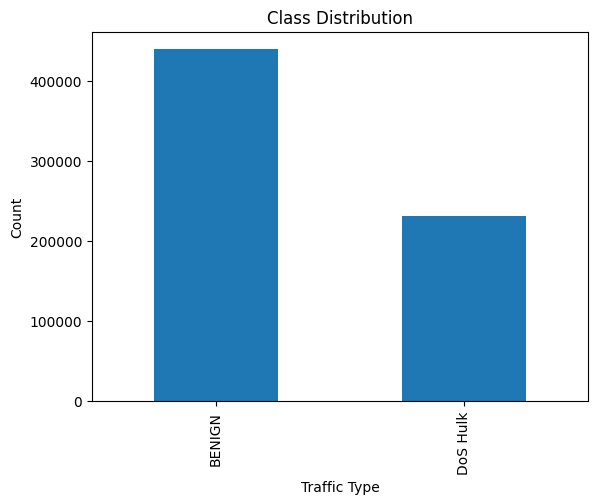

In [31]:
import matplotlib.pyplot as plt
df[' Label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Count")
plt.show()

In [32]:
print(df.columns.tolist())
print(df.shape)

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [33]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Keep only numeric columns
X = df.select_dtypes(include=np.number)
# Remove NaN and infinity values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
print("Shape after cleaning:", X.shape)

Shape after cleaning: (669807, 78)


In [34]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(669807, 78)


In [35]:
import torch
from torch.utils.data import TensorDataset, DataLoader
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset,batch_size=128,shuffle=True)
print("Feature count:", X_scaled.shape[1])

Feature count: 78


In [36]:
for batch, in loader:
    print(batch.shape)
    break

torch.Size([128, 78])


In [37]:
feature_dim = X_scaled.shape[1]
latent_dim = 100
print("Feature Dimension:", feature_dim)

Feature Dimension: 78


In [38]:
import torch.nn as nn
latent_dim = 100
feature_dim = 78
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, feature_dim),
            nn.Sigmoid())
    def forward(self, z):
        return self.model(z)
generator = Generator()

In [39]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            )
    def forward(self, x):
        return self.model(x)
discriminator = Discriminator()

In [40]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = generator.to(device)
discriminator = discriminator.to(device)
criterion = nn.BCEWithLogitsLoss()
g_optimizer = torch.optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5, 0.999))
epochs = 50
g_losses = []
d_losses = []

In [41]:
for epoch in range(epochs):
    for real_batch, in loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        # Train Discriminator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_batch = generator(z)
        real_loss = criterion(discriminator(real_batch),real_labels)
        fake_loss = criterion(discriminator(fake_batch.detach()),fake_labels)
        d_loss = real_loss + fake_loss
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()
        # Train Generator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_batch = generator(z)
        g_loss = criterion(discriminator(fake_batch),real_labels)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"D Loss={d_loss:.4f} "
        f"G Loss={g_loss:.4f}"
    )

Epoch 1/50 D Loss=0.7505 G Loss=1.3893
Epoch 2/50 D Loss=0.6865 G Loss=1.5362
Epoch 3/50 D Loss=0.7620 G Loss=1.4412
Epoch 4/50 D Loss=0.6691 G Loss=1.4642
Epoch 5/50 D Loss=0.6568 G Loss=1.5054
Epoch 6/50 D Loss=0.5633 G Loss=1.6105
Epoch 7/50 D Loss=0.5737 G Loss=1.6952
Epoch 8/50 D Loss=0.7706 G Loss=1.3899
Epoch 9/50 D Loss=0.6454 G Loss=1.5779
Epoch 10/50 D Loss=0.6468 G Loss=1.5002
Epoch 11/50 D Loss=0.6730 G Loss=1.4541
Epoch 12/50 D Loss=0.6158 G Loss=1.6255
Epoch 13/50 D Loss=0.9069 G Loss=1.3678
Epoch 14/50 D Loss=0.7346 G Loss=1.4189
Epoch 15/50 D Loss=0.7174 G Loss=1.3510
Epoch 16/50 D Loss=0.6536 G Loss=1.5805
Epoch 17/50 D Loss=0.6755 G Loss=1.8323
Epoch 18/50 D Loss=0.7200 G Loss=1.3608
Epoch 19/50 D Loss=0.5638 G Loss=1.7804
Epoch 20/50 D Loss=0.5948 G Loss=2.0529
Epoch 21/50 D Loss=0.7318 G Loss=1.1310
Epoch 22/50 D Loss=0.6190 G Loss=2.2587
Epoch 23/50 D Loss=0.5674 G Loss=2.3686
Epoch 24/50 D Loss=0.6370 G Loss=2.0453
Epoch 25/50 D Loss=0.5621 G Loss=2.4118
Epoch 26/

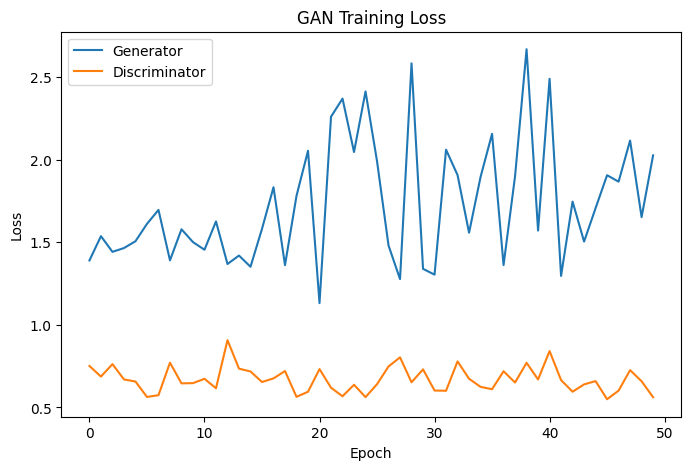

In [42]:
plt.figure(figsize=(8,5))
plt.plot(g_losses, label='Generator')
plt.plot(d_losses, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Loss')
plt.legend()
plt.show()

In [42]:
with torch.no_grad():
    z = torch.randn(5000, latent_dim).to(device)
    synthetic_data = generator(z).cpu().numpy()
print(synthetic_data.shape)

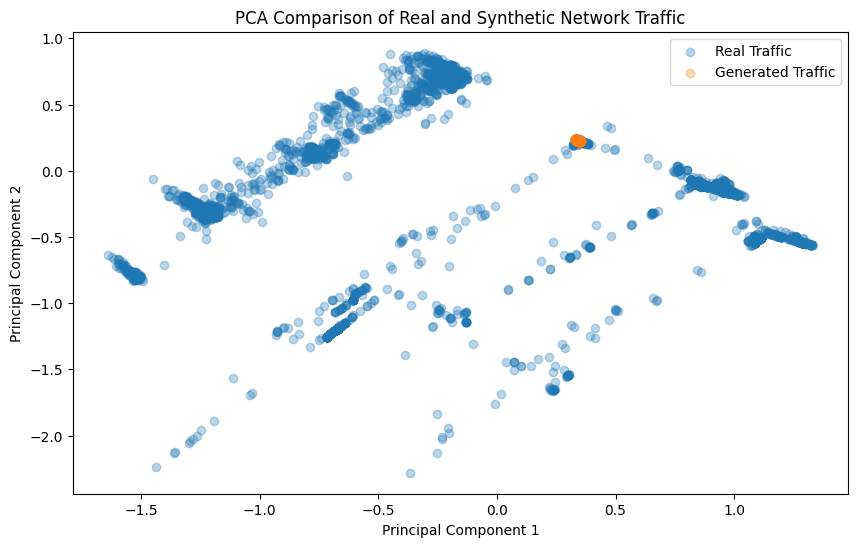

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
generator.eval()
with torch.no_grad():
    z = torch.randn(5000, latent_dim).to(device)
    synthetic_data = generator(z).cpu().numpy()
real_sample = X_scaled[:5000]
pca = PCA(n_components=2)
real_pca = pca.fit_transform(real_sample)
fake_pca = pca.transform(synthetic_data)
plt.figure(figsize=(10,6))
plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    alpha=0.3,
    label='Real Traffic'
)
plt.scatter(
    fake_pca[:,0],
    fake_pca[:,1],
    alpha=0.3,
    label='Generated Traffic'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Comparison of Real and Synthetic Network Traffic")
plt.legend()
plt.show()

In [46]:
real_mean = np.mean(real_sample, axis=0)
fake_mean = np.mean(synthetic_data, axis=0)
mean_difference = np.mean(
    np.abs(real_mean - fake_mean)
)
print("Mean Feature Difference:", mean_difference)

Mean Feature Difference: 0.04478852121269431


# Part 2.3 – Creative AI: QuickDraw Birthday Cake Generation

### Objective
Train a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic birthday cake sketches using the Google QuickDraw dataset.

### Dataset
Google QuickDraw – Birthday Cake Category

### Tasks Performed
- Downloaded and explored birthday cake sketches
- Visualised sample drawings
- Preprocessed images for GAN training
- Built a DCGAN architecture
- Trained the model on sketch images
- Generated synthetic birthday cake sketches
- Compared real and generated sketches

### Outputs
- Sample Sketch Visualisations
- Training Loss Curves
- Generated Birthday Cake Sketches
- Real vs Generated Comparisons

In [75]:
import requests
import numpy as np
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday cake.npy"
response = requests.get(url)
with open("birthday_cake.npy", "wb") as f:
    f.write(response.content)
cakes = np.load("birthday_cake.npy")
print(cakes.shape)

(144982, 784)


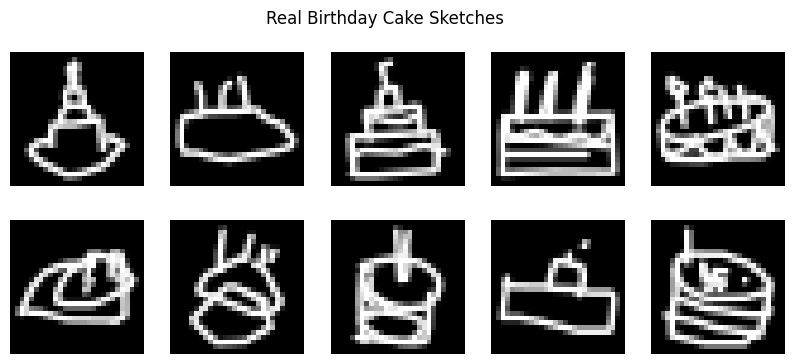

In [76]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,5, figsize=(10,4))
for i in range(10):
    img = cakes[i].reshape(28,28)
    axes[i//5,i%5].imshow(img, cmap='gray')
    axes[i//5,i%5].axis('off')
plt.suptitle("Real Birthday Cake Sketches")
plt.show()

In [77]:
cakes = cakes.astype(np.float32)
cakes = (cakes / 127.5) - 1
cakes = cakes.reshape(-1,1,28,28)
cakes = cakes[:50000]
print(cakes.shape)

(50000, 1, 28, 28)


In [78]:
import torch
from torch.utils.data import TensorDataset, DataLoader
cake_tensor = torch.tensor(cakes)
dataset = TensorDataset(cake_tensor)
loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [79]:
import torch.nn as nn
latent_dim = 100
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim,256,7,1,0,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128,1,4,2,1,bias=False),
            nn.Tanh()
        )
    def forward(self,z):
        return self.model(z)

In [80]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128*7*7,1)
        )
    def forward(self,x):
        return self.model(x)

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)
criterion = nn.BCEWithLogitsLoss()
g_optimizer = torch.optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))
epochs = 30

In [82]:
g_losses = []
d_losses = []
for epoch in range(epochs):
    for real_images, in loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)
        z = torch.randn(batch_size,latent_dim,1,1).to(device)
        fake_images = generator(z)
        real_loss = criterion(
            discriminator(real_images),
            real_labels
        )
        fake_loss = criterion(
            discriminator(
                fake_images.detach()
            ),
            fake_labels
        )
        d_loss = real_loss + fake_loss
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()
        z = torch.randn(batch_size,latent_dim,1,1).to(device)
        fake_images = generator(z)
        g_loss = criterion(
            discriminator(fake_images),
            real_labels
        )
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"D={d_loss:.4f} "
        f"G={g_loss:.4f}"
    )

Epoch 1/30 D=0.3444 G=2.1574
Epoch 2/30 D=0.2493 G=3.1153
Epoch 3/30 D=0.1379 G=2.5375
Epoch 4/30 D=0.2893 G=1.9308
Epoch 5/30 D=0.1500 G=3.3827
Epoch 6/30 D=0.1605 G=3.6163
Epoch 7/30 D=0.1507 G=3.6701
Epoch 8/30 D=0.3136 G=1.9813
Epoch 9/30 D=0.1927 G=2.5642
Epoch 10/30 D=0.2176 G=3.0657
Epoch 11/30 D=0.1042 G=3.4396
Epoch 12/30 D=0.0797 G=3.8042
Epoch 13/30 D=0.0801 G=3.3608
Epoch 14/30 D=0.2320 G=4.3105
Epoch 15/30 D=0.1049 G=4.5526
Epoch 16/30 D=0.0582 G=3.9237
Epoch 17/30 D=2.7652 G=2.5029
Epoch 18/30 D=0.1477 G=3.5237
Epoch 19/30 D=0.0669 G=4.0167
Epoch 20/30 D=0.0777 G=4.6487
Epoch 21/30 D=0.0690 G=5.1955
Epoch 22/30 D=0.0495 G=4.0273
Epoch 23/30 D=0.0358 G=5.3520
Epoch 24/30 D=0.1756 G=5.0727
Epoch 25/30 D=1.8270 G=5.0892
Epoch 26/30 D=0.1196 G=3.8292
Epoch 27/30 D=0.0743 G=5.2932
Epoch 28/30 D=0.1311 G=4.0592
Epoch 29/30 D=0.0537 G=4.0951
Epoch 30/30 D=0.0365 G=4.9483


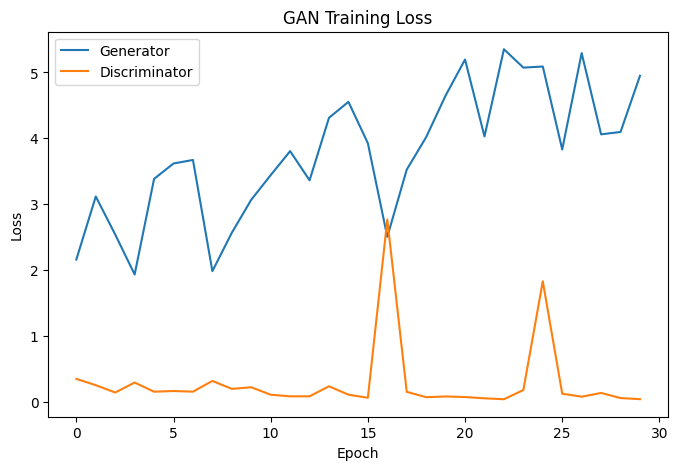

In [83]:
plt.figure(figsize=(8,5))
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.show()

In [84]:
generator.eval()
with torch.no_grad():
    z = torch.randn(25,latent_dim,1,1).to(device)
    fake = generator(z).cpu()
fake = (fake + 1) / 2

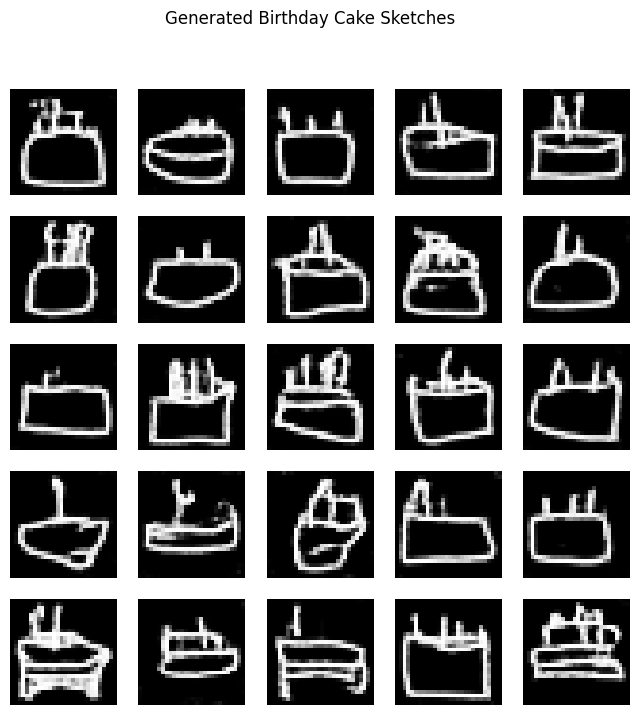

In [85]:
fig, axes = plt.subplots(5,5,figsize=(8,8))
for i in range(25):
    axes[i//5,i%5].imshow(
        fake[i,0],
        cmap='gray'
    )
    axes[i//5,i%5].axis('off')
plt.suptitle(
    "Generated Birthday Cake Sketches"
)
plt.show()

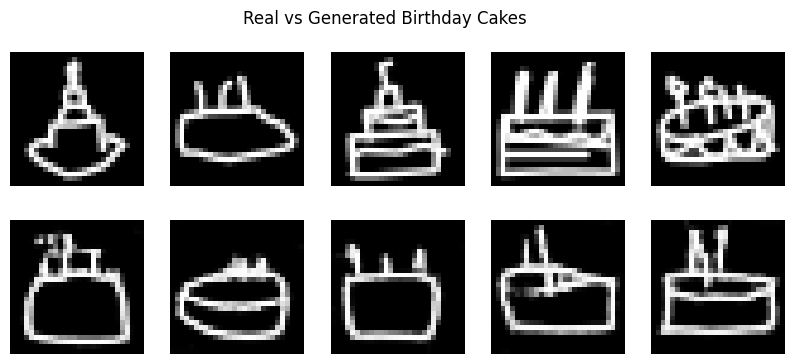

In [86]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10,4)
)
for i in range(5):
    axes[0,i].imshow(
        cakes[i,0],
        cmap='gray'
    )
    axes[0,i].axis('off')
for i in range(5):
    axes[1,i].imshow(
        fake[i,0],
        cmap='gray'
    )
    axes[1,i].axis('off')
plt.suptitle(
    "Real vs Generated Birthday Cakes"
)
plt.show()